In [1]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import string
import re

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

# ignore harmless warning
import warnings
warnings.filterwarnings('ignore')

In [2]:
#load data
data = pd.read_csv("ResumeDataSet.csv")
data.head()


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [ ]:
data.shape

(962, 2)

In [ ]:
data['Category'].value_counts().index

Index(['Java Developer', 'Testing', 'DevOps Engineer', 'Python Developer',
       'Web Designing', 'HR', 'Hadoop', 'Sales', 'Data Science',
       'Mechanical Engineer', 'ETL Developer', 'Blockchain',
       'Operations Manager', 'Arts', 'Database', 'Health and fitness', 'PMO',
       'Electrical Engineering', 'Business Analyst', 'DotNet Developer',
       'Automation Testing', 'Network Security Engineer', 'Civil Engineer',
       'SAP Developer', 'Advocate'],
      dtype='object', name='Category')

In [ ]:
len(data['Category'].value_counts().index)

25

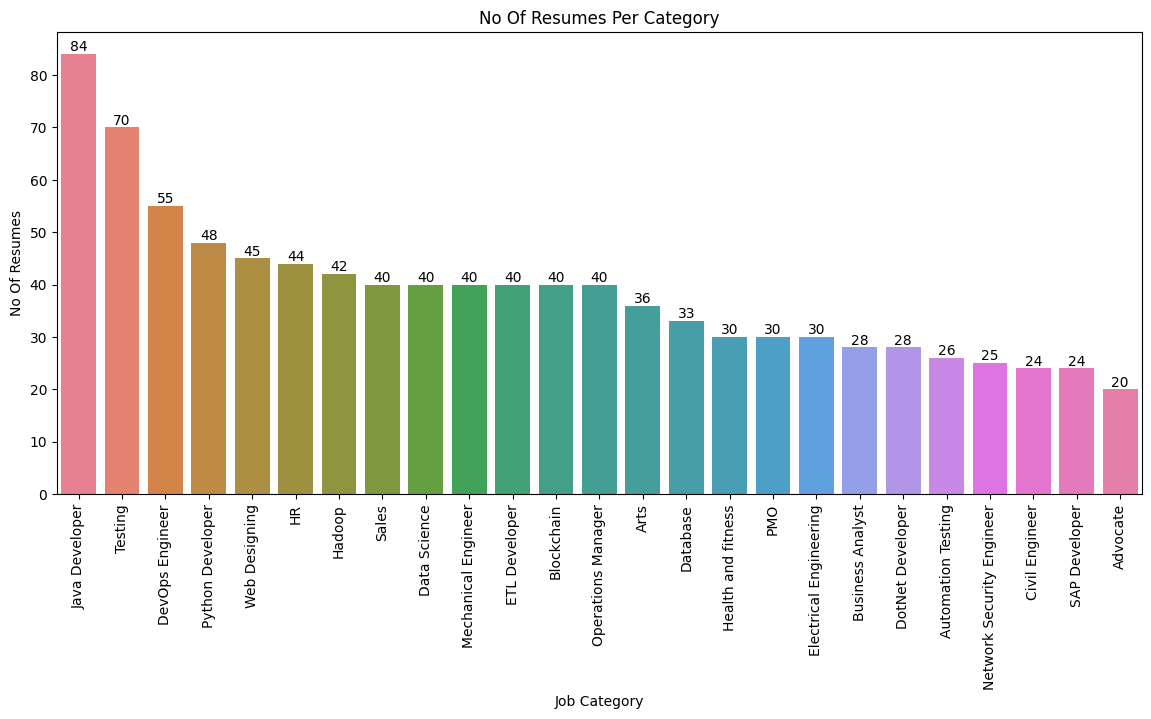

In [ ]:
plt.figure(figsize=(14,6))
ax = sns.barplot(x=data['Category'].value_counts().index, # xaxis = categorical
                 y=data['Category'].value_counts().values, # numerical variable
                 hue=data['Category'].value_counts().index, # each category will get 1 single
                 )
for val in range(len(data['Category'].value_counts().index)):
    ax.bar_label(ax.containers[val])
# Container is just a python object that holds all the bar
#ax.containers[0] = this adds the label the first bar,

plt.xticks(rotation=90)
plt.xlabel('Job Category')
plt.ylabel('No Of Resumes')
plt.title('No Of Resumes Per Category')
plt.show()

In [ ]:
ax.containers[2]

<BarContainer object of 1 artists>

In [ ]:
data['Category'].value_counts().index

Index(['Java Developer', 'Testing', 'DevOps Engineer', 'Python Developer',
       'Web Designing', 'HR', 'Hadoop', 'Sales', 'Data Science',
       'Mechanical Engineer', 'ETL Developer', 'Blockchain',
       'Operations Manager', 'Arts', 'Database', 'Health and fitness', 'PMO',
       'Electrical Engineering', 'Business Analyst', 'DotNet Developer',
       'Automation Testing', 'Network Security Engineer', 'Civil Engineer',
       'SAP Developer', 'Advocate'],
      dtype='object', name='Category')

In [ ]:
data['Category'].value_counts().values

array([84, 70, 55, 48, 45, 44, 42, 40, 40, 40, 40, 40, 40, 36, 33, 30, 30,
       30, 28, 28, 26, 25, 24, 24, 20])

In [ ]:
print('Category : ' , data['Category'][0])

print ('Resume Preview : \n')
print(data['Resume'][0])

Category :  Data Science
Resume Preview : 

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Fraud

In [ ]:
for i in range(5) :
  print(f' Resume{i+1}')
  print('Category :' , data['Category'][i])

 Resume1
Category : Data Science
 Resume2
Category : Data Science
 Resume3
Category : Data Science
 Resume4
Category : Data Science
 Resume5
Category : Data Science


In [ ]:
for i in range(5) :
  print(f'\nResume{i+1}')
  print('Category :' , data['Category'][i])
  print('Resume Preview :', data['Resume'][i][:300])


Resume1
Category : Data Science
Resume Preview : Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language pr

Resume2
Category : Data Science
Resume Preview : Education Details 
May 2013 to May 2017 B.E   UIT-RGPV
Data Scientist 

Data Scientist - Matelabs
Skill Details 
Python- Exprience - Less than 1 year months
Statsmodels- Exprience - 12 months
AWS- Exprience - Less than 1 year months
Machine learning- Exprience - Less than 1 year months
Skl

Resume3
Category : Data Science
Resume Preview : Areas of Interest Deep Learning, Control System Design, Programming in-Python, Electric Machinery, Web Development, Analytics Technical Activities q Hindustan Aeronautics Limited, Bangalore - For 4 weeks under the guidance of Mr. Satish, Senior Engineer in t

In [ ]:
random_resumes = data.sample(n=5)  #Gurpreet's code

for i, row in enumerate(random_resumes.itertuples(), 1):
    print(f'Resume {i}:')
    print(row.Resume)
    print(f'Category: {row.Category}')
    print('Resume Preview :', row.Resume[:300])


Resume 1:
Education Details 
January 2014  Education Details Pune, Maharashtra University Of Pune
January 2010 B.Com  Pune, Maharashtra University Of Pune
Software Developer 

Software Developer - Technology - Dot Net
Skill Details 
Company Details 
company - Technology - Dot Net
description - â¢ Previous Experience worked in SepSoft ERP  Solutions From 1-Jan 2016  To 24th Dec 2016.

â¢ Designation - Software Developer.
â¢ Technology - Dot Net
Category: DotNet Developer
Resume Preview : Education Details 
January 2014  Education Details Pune, Maharashtra University Of Pune
January 2010 B.Com  Pune, Maharashtra University Of Pune
Software Developer 

Software Developer - Technology - Dot Net
Skill Details 
Company Details 
company - Technology - Dot Net
description - â¢ Pr
Resume 2:
SOFTWARE SKILLS: â¢ General Computer Proficiency â¢ Program Langages known C, C+, Java, Web Programming â¢ Tools & Software know MATLAB. DBMS KEY STRENGTHS: â¢ Posse's Good communication and analytic

In [ ]:
random_indices = random.sample(range(len(data)), 5) #Divakar's code

for i, idx in enumerate(random_indices):
  print(f'resume{i+1}')
  print(data["Category"][idx])
  print(data["Resume"][idx])


resume1
Civil Engineer
COMPUTER KNOWLEDGE â¢ Drafting tools: AutoCAD. â¢ Packages: MS Office Applications â¢ Operating systems: Windows 9x/2000/XP/Vista. DETAILEXPERIENCES Experience in India: 1) Working Experience at ALIA CONSTRUCTION AT NALLASOPARA (WEST) Mumbai since JUNE 2014 to MAY 2015. As a Civil Engineer (1 years) Project handle: Project title: YASHWANT ORICHIDS Position: Site Engineer Location: Nallasopara (W) Mumbai Maharashtra - 400097 IndiaEducation Details 
 S.S.C Rajasthan board  excellence polytechnic college
CIVIL ENGINEER 

CIVIL ENGINEER - Site Encharge
Skill Details 
AutoCAD.- Exprience - 9 months
Civil Engineer- Exprience - 42 months
Drafting- Exprience - 9 months
Engineer- Exprience - 42 months
MS Office- Exprience - 9 monthsCompany Details 
company - Site Encharge
description - Location: Andheri (E) Marol Bus Depot, near Maruti High School, MIDC
Mumbai Maharashtra 400093 India

Experience in UAE:
1) Currently Working at NOVA ENGINEERING WORKS Since MAY 2018 to 

In [ ]:
# generate 5 random resumes

for i in [random.randint(1, len(data)) for cnt in range(5)]:
    print(f'\n--- Resume {i+1} ---')
    print('Category:', data['Category'][i])
    print('Resume Preview:', data['Resume'][i][:300])


--- Resume 862 ---
Category: Blockchain
Resume Preview: SKILLS Bitcoin, Ethereum Solidity Hyperledger, Beginner Go, Beginner R3 Corda, Beginner Tendermint, Nodejs, C Programming, Java, Machine Learning specilaized in Brain Computer Interface, Computer Networking and Server Admin, Computer Vision, Data Analytics, Cloud Computing, Reactjs, angularEducation

--- Resume 863 ---
Category: Blockchain
Resume Preview: Hobbies â¢ Playing Chess â¢ Solving Rubik's Cube â¢ Watching Series Languages â¢ English â¢ Hindi â¢ Marathi Education Details 
January 2014 to January 2017 Bachelorâs Degree Information Technology, First Class Pune, Maharashtra JSPMâs Jayawantrao Sawant College of Engineering
January 20

--- Resume 97 ---
Category: Advocate
Resume Preview: Education Details 
 LLB.   Dibrugarh University
Advocate 


Skill Details 
Legal.- Exprience - Less than 1 year monthsCompany Details 
company - Legal.
description - â¢ Advocate

--- Resume 642 ---
Category: DevOps Engineer
Resume 

In [ ]:
data['Category'].value_counts().index

Index(['Java Developer', 'Testing', 'DevOps Engineer', 'Python Developer',
       'Web Designing', 'HR', 'Hadoop', 'Sales', 'Data Science',
       'Mechanical Engineer', 'ETL Developer', 'Blockchain',
       'Operations Manager', 'Arts', 'Database', 'Health and fitness', 'PMO',
       'Electrical Engineering', 'Business Analyst', 'DotNet Developer',
       'Automation Testing', 'Network Security Engineer', 'Civil Engineer',
       'SAP Developer', 'Advocate'],
      dtype='object', name='Category')

In [ ]:
data['Category'].value_counts().max()

84

In [ ]:

# max number of resumes of all categories.now max= 84 i have to balance all the counts of categories to 84
max_size = data['Category'].value_counts().max()

# oversample of the minority class to mathc the max counts
balanced_df = data.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)
balanced_df

,Category,Resume
0,Advocate,Good grasping quality and skillful work Educat...
1,Advocate,SKILLS â¢ Knows English as native speaker (IE...
2,Advocate,Education Details \r\n LLB. Dibrugarh Univer...
3,Advocate,SKILLS â¢ Knows English as native speaker (IE...
4,Advocate,â¢ Hard working â¢ Quick learnerEducation De...
...,...,...
2095,Web Designing,"Technical Skills Web Technologies: Angular JS,..."
2096,Web Designing,Education Details \r\n B.C.A Bachelor Computer...
2097,Web Designing,Education Details \r\n B.C.A Bachelor Computer...
2098,Web Designing,"Technical Skills Web Technologies: Angular JS,..."


In [ ]:
data['Category'].value_counts().values

array([84, 70, 55, 48, 45, 44, 42, 40, 40, 40, 40, 40, 40, 36, 33, 30, 30,
       30, 28, 28, 26, 25, 24, 24, 20])

In [ ]:
#data Balancing
# goal is to have max= 84  resumes (in this case) in each category by oversmapling. where random resumes from
#each category will be picked and added to that particular category

# max number of resumes of all categories.now max= 84 i have to balance all the counts of categories to 84
max_size = data['Category'].value_counts().max()

# oversample of the minority class to mathc the max counts
balanced_df = data.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)
balanced_df

#shuffle and mix the data randomly
data = balanced_df.sample(frac=1).reset_index(drop = True)

#data sample after shuffle
data.head()


,Category,Resume
0,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
1,Hadoop,Technical Skill Set: Programming Languages Apa...
2,Java Developer,Education Details \r\nJanuary 2013 Master of E...
3,Data Science,"SKILLS C Basics, IOT, Python, MATLAB, Data Sci..."
4,Blockchain,"SOFTWARE SKILLS: Languages: C, C++ & java Oper..."


In [ ]:
def clean_resume(txt):

    # remove the url
    clean_text = re.sub(r'http\S+', '', txt.lower())

    # remove hatag
    clean_text = re.sub(r"\S+@\S+", '', clean_text)

    # remove mentions
    clean_text = re.sub(r'@\S+', '',clean_text)

    # remove the special characters and punctuations
    clean_text = re.sub(r'[%s]' % re.escape(string.punctuation), '' ,clean_text)

    # remove non ascii characters
    clean_text = re.sub(r'[^\x00-\x7f]', '', clean_text) # if any emojis

    # replace multiple space with single space
    clean_text = re.sub(r'\s{2,}', ' ', clean_text)

    # strip the leading and trailing spaces
    clean_text = clean_text.strip()

    return clean_text

In [ ]:
test_text = "#### Hello!!! My resume is available at https://github.com/username. Reach me @ my_email123@gmail.com. Skills: Python, NLP, AI, ML, Deep Learning!!! $$$"
print(clean_resume(test_text))

hello my resume is available at reach me skills python nlp ai ml deep learning


In [ ]:
# clean all resume data
data['clean_resume'] = data['Resume'].apply(clean_resume)

In [ ]:
# untreated version of the first resume
print(data['Resume'][2])

Education Details 
January 2013 Master of Engineering Information Technology Pune, Maharashtra M.I.T
January 2005 Bachelor of Engineering Information Technology Pusad, Maharashtra Amravati University
January 2001   Pusad, Maharashtra P. N. Junior College
January 1999 S.S.C  Pusad, Maharashtra K.D. High-School
Java Developer 

Java Developer - Maxgen Technologies
Skill Details 
Company Details 
company - Maxgen Technologies
description - Currently working in Infrasoft Technologies, Andheri as a Java Developer.
company - MIS Generation of Tata Sky and Tata Power
description - COURSES DONE: Android -Mobile App Development, Technologies in Java-Core Java,
Advance Java, JSF, Hibernate, Spring at NIIT in 2015-16.

ANDROID PROJECT: Location Detector of Computing and Mobile Devices. (Android)

ME PROJECT: Data Deduplication. My projects works to reduce redundant data from the system and free up the memory. It stores unique copy of data and for more location with same data with the help of poin

In [ ]:
# treated version of the first resume
print(data['clean_resume'][2])
print(len(data['clean_resume'][2]))

education details january 2013 master of engineering information technology pune maharashtra mit january 2005 bachelor of engineering information technology pusad maharashtra amravati university january 2001 pusad maharashtra p n junior college january 1999 ssc pusad maharashtra kd highschool java developer java developer maxgen technologies skill details company details company maxgen technologies description currently working in infrasoft technologies andheri as a java developer company mis generation of tata sky and tata power description courses done android mobile app development technologies in javacore java advance java jsf hibernate spring at niit in 201516 android project location detector of computing and mobile devices android me project data deduplication my projects works to reduce redundant data from the system and free up the memory it stores unique copy of data and for more location with same data with the help of pointers can access the data java subjects taught c lang

In [ ]:
# dependency split
x = data['clean_resume']
y = data['Category']

In [ ]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [ ]:
# vectorization
vectorizer = TfidfVectorizer(stop_words='english')
x_train_vector = vectorizer.fit_transform(x_train)
x_test_vector = vectorizer.transform(x_test) # no fit() to avoid data leakage

Training Score: 99.88 %
Testing Score: 99.29 %

Classification Report:

                            precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00        16
                     Arts       1.00      1.00      1.00        11
       Automation Testing       1.00      1.00      1.00        13
               Blockchain       1.00      1.00      1.00        21
         Business Analyst       1.00      1.00      1.00        20
           Civil Engineer       1.00      1.00      1.00        24
             Data Science       1.00      1.00      1.00        18
                 Database       1.00      1.00      1.00        14
          DevOps Engineer       1.00      0.85      0.92        20
         DotNet Developer       1.00      1.00      1.00        16
            ETL Developer       1.00      1.00      1.00        14
   Electrical Engineering       1.00      1.00      1.00        18
                       HR       1.00      1.00      1.0

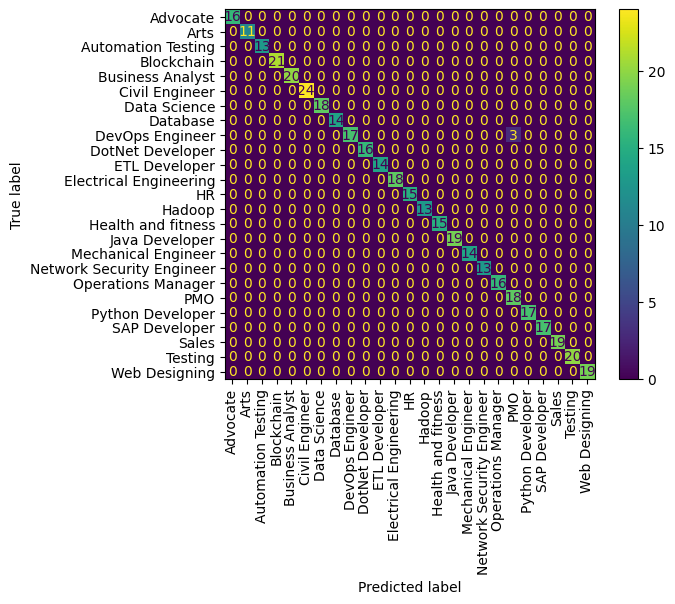

In [ ]:
# Classification Model
x_train_dense = x_train_vector.toarray()
x_test_dense = x_test_vector.toarray()

# initalize and train the model
knn_model = OneVsRestClassifier(KNeighborsClassifier())
knn_model.fit(x_train_dense, y_train)

# evaluate the results
print('Training Score:', round(knn_model.score(x_train_dense, y_train)*100, 2), '%')
y_pred_knn = knn_model.predict(x_test_dense)
print('Testing Score:', round(accuracy_score(y_test, y_pred_knn)*100,2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, xticks_rotation='vertical')
print('\nClassification Report:\n\n', classification_report(y_test, y_pred_knn))

In [ ]:
# Prediction for new incoming resume

def predict_resume_category(input_resume):
    # preprocess the input
    cleaned_text = clean_resume(input_resume)

    # vectorize the input
    vectorized_text = vectorizer.transform([cleaned_text])

    # convert to dense array
    dense_array_text = vectorized_text.toarray()

    # predict the input by passing it onto trained model
    predicted_label = knn_model.predict(dense_array_text)

    print('Predicted category:', predicted_label[0])

In [ ]:
myresume = """I am a data scientist specializing in machine
learning, deep learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms, and designing computer vision
systems. My technical skills include proficiency in
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects, I am
eager to contribute my expertise. Let's harness the
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: 611noorsaeed@gmail.com
Phone: 03442826192
Github: https://github.com/611noorsaeed
Linkdin: https://www.linkedin.com/in/noor-saeed654a23263/
Blogs: https://medium.com/@611noorsaeed
Youtube: Artificial Intelligence
ABOUT ME
WORK EXPERIENCE
SKILLES
NOOR SAEED
LANGUAGES
English
Urdu
Hindi
I am a versatile data scientist with expertise in a wide
range of projects, including machine learning,
recommendation systems, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models
to solve complex problems and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visualization
Programming Languages (Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statistical Analysis
Communication and Collaboration
"""

predict_resume_category(myresume)

Predicted category: Data Science


In [ ]:
# HR Resume
resume_sample = '''Results-driven people operations professional with experience in recruitment, onboarding, and employee engagement.
Skilled in end-to-end hiring, workforce coordination, and performance management processes.
Strong knowledge of labor laws, payroll coordination, and compliance requirements.
Adept at fostering a positive workplace culture and handling employee relations effectively.
Proficient in people management systems, MS Excel, and data-driven reporting.'''

predict_resume_category(resume_sample)

Predicted category: HR


In [ ]:
# H&F Resume
resume_sample = '''Dedicated professional focused on improving strength, endurance, and overall physical performance.
Experienced in designing structured workout programs for beginners and advanced individuals.
Strong understanding of exercise techniques, form correction, and movement efficiency.
Skilled in guiding members through safe and effective training routines.
Adept at motivating individuals to stay consistent and committed to their goals.
Knowledgeable in muscle conditioning, flexibility, and recovery techniques.
Experienced in tracking progress through performance-based metrics.
Capable of modifying routines based on individual progress and limitations.
Familiar with basic nutrition guidance to support training outcomes.
Effective at educating members on proper equipment usage and injury prevention.
Strong communication skills to build trust and long-term member relationships.
Comfortable working with diverse age groups and ability levels.
Focused on sustainable results through disciplined training approaches.
Committed to maintaining a positive and energetic training environment.
Dedicated to helping members unlock their physical potential safely.'''

predict_resume_category(resume_sample)

Predicted category: Operations Manager
